<div style=" background-color: RGB(0,114,200);" >

<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Examen Data science 1</h1>

<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Santé Diagnoctic intelligent par image

</h2>

</div>

In [ ]:
#Projet de détection de pneumonie avec CNN

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)


TensorFlow version: 2.13.0
NumPy version: 1.23.0
Pandas version: 1.5.0


In [ ]:
# Etape charger les les images 

In [ ]:
#  Étape  – Recréer les générateurs d’images proprement

In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_dir = r"C:\Users\HP\Desktop\Mastère1 Big Data & Data Strategie\Data science 1\archive\chest_xray"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=16,
    class_mode='binary',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=16,
    class_mode='binary',
    shuffle=False
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [ ]:
# Étape  – Construire le modèle

In [15]:
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
# Étape  – Entraînement avec validation activée

In [16]:
history = model.fit(
    train_data,
    epochs=5,
    steps_per_epoch=train_data.samples // train_data.batch_size,
    validation_data=val_data,
    validation_steps=val_data.samples // val_data.batch_size
)


Epoch 1/5
326/326 [==============================] - 101s 307ms/step - loss: 0.2261 - accuracy: 0.9256 - val_loss: 0.2211 - val_accuracy: 0.8750
Epoch 2/5
326/326 [==============================] - 96s 293ms/step - loss: 0.1090 - accuracy: 0.9609 - val_loss: 0.2202 - val_accuracy: 0.8750
Epoch 3/5
326/326 [==============================] - 100s 308ms/step - loss: 0.0670 - accuracy: 0.9757 - val_loss: 0.1094 - val_accuracy: 1.0000
Epoch 4/5
326/326 [==============================] - 94s 290ms/step - loss: 0.0524 - accuracy: 0.9806 - val_loss: 0.2150 - val_accuracy: 0.8750
Epoch 5/5
326/326 [==============================] - 98s 300ms/step - loss: 0.0310 - accuracy: 0.9887 - val_loss: 0.3077 - val_accuracy: 0.8125


In [ ]:
#verifications des clés historiques

In [17]:
print("Clés du dictionnaire 'history':")
print(history.history.keys())


Clés du dictionnaire 'history':
dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


In [ ]:
#visualisations de la courbes

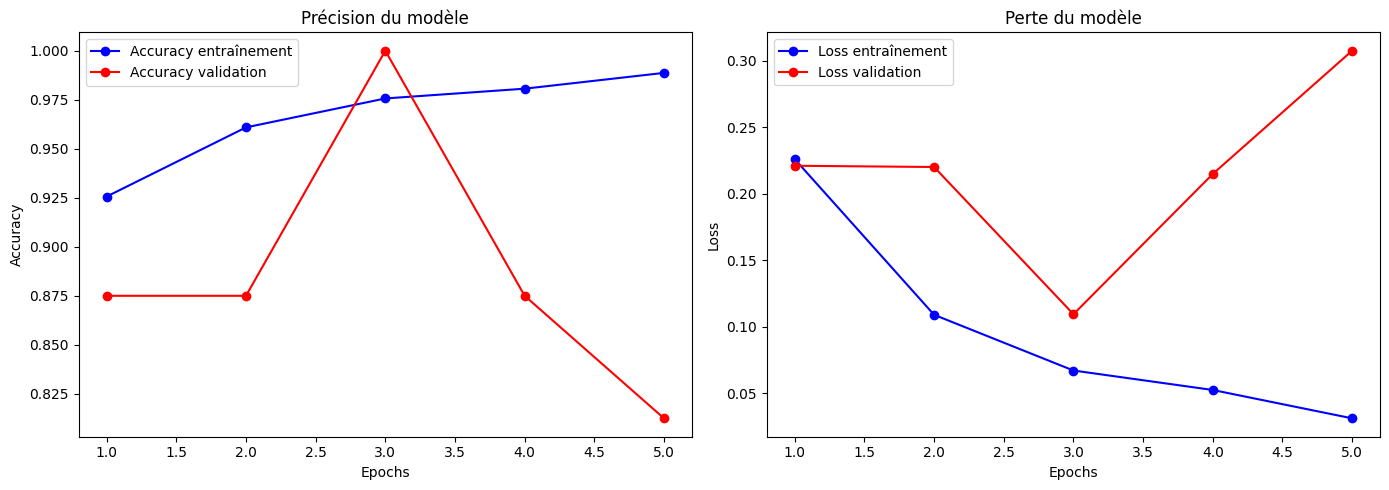

In [18]:
import matplotlib.pyplot as plt

# Récupération des métriques
acc = history.history['accuracy']
val_acc = history.history.get('val_accuracy', [])  # S'il existe
loss = history.history['loss']
val_loss = history.history.get('val_loss', [])

epochs = range(1, len(acc) + 1)

# Tracé des courbes
plt.figure(figsize=(14, 5))

# Précision
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Accuracy entraînement')
if val_acc:
    plt.plot(epochs, val_acc, 'ro-', label='Accuracy validation')
plt.title('Précision du modèle')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Perte
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Loss entraînement')
if val_loss:
    plt.plot(epochs, val_loss, 'ro-', label='Loss validation')
plt.title('Perte du modèle')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Évaluation du modèle sur les données de test

In [19]:
# Évaluation sur le set de test
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy: {:.2f}%".format(test_acc * 100))


20/20 [==============================] - 5s 235ms/step - loss: 2.0876 - accuracy: 0.7099
Test Accuracy: 70.99%


In [ ]:
#Prédiction sur une nouvelle image

In [20]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Chemin vers une image du dossier test
img_path = r"C:\Users\HP\Desktop\Mastère1 Big Data & Data Strategie\Data science 1\archive\chest_xray\test\PNEUMONIA\person100_bacteria_475.jpeg"

# Charger et préparer l'image
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normaliser

# Prédire
prediction = model.predict(img_array)

# Afficher le résultat
if prediction[0] > 0.5:
    print("Prédiction : PNEUMONIA ({:.2f}%)".format(prediction[0][0]*100))
else:
    print("Prédiction : NORMAL ({:.2f}%)".format((1 - prediction[0][0])*100))


1/1 [==============================] - 1s 633ms/step
Prédiction : PNEUMONIA (100.00%)


In [ ]:
#sauvegarde du modele

In [21]:
model.save("pneumonia_model.h5")
print("Modèle sauvegardé sous pneumonia_model.h5")


C:\Users\HP\anaconda3\envs\tf-env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Modèle sauvegardé sous pneumonia_model.h5
